In [1]:
# ------------------------------------------------------------
# STEP 1: LOAD DATA
# ------------------------------------------------------------

import pandas as pd
import numpy as np

url = "gs://agntworks-data-dev/sandbox/experiments/XODM-quotes-trips-2016.xlsx"

# Load  data
df = pd.read_excel(url, engine="openpyxl")

print("Shape:", df.shape)
df.head()

Shape: (22708, 59)


,ID,Quote_ID,Confirmation_Number,Date_Quoted,PAX_ID,Trip_ID,Trip_KID_Date,Trip_Number,Trip_Status,qTrip_type_code,...,Pass_FT_Fixed,Client_Invoice_Comment,Base_Code,Last_Update_Date,Payment_1,Payment_Date_1,Payment_Type_1,AC_Cost_Total,Owner_AC_Cost,Owner_AC_Cost_Fixed
0,362002,423681001GEOA08,568956,2015-12-31,3939244FOUL1871,0,NaT,NaN,NaN,RETA,...,0,0,0,2015-12-31,0.0,NaT,0,24000.0,0.0,0
1,362003,423681017GEOA08,568957,2015-12-31,421851225STEB01,423681017GEOA015,2015-12-31,174284.0,Cancelled,WHSL,...,0,0,0,2016-01-01,0.0,NaT,0,0.0,0.0,0
2,362005,423681029GEOA08,568958,2015-12-31,41210923STEB01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,72750.0,0.0,0
3,362004,423681030SERD08,568959,2015-12-31,39552284MURC01,423681030SERD015,2015-12-31,174295.0,Completed,WHSL,...,0,0,0,2016-01-13,12937.5,2016-01-06,102,20350.0,0.0,0
4,362006,423681055GEOA08,568960,2015-12-31,415961361GEOA01,0,NaT,NaN,NaN,RETA,...,0,0,120,2015-12-31,0.0,NaT,0,38850.0,0.0,0


In [2]:
# ------------------------------------------------------------
# STEP 2: DATE CLEANING
# ------------------------------------------------------------

# Convert relevant columns to datetime
df["Date_Quoted"] = pd.to_datetime(df["Date_Quoted"], errors="coerce")
df["Trip_Departure_Date"] = pd.to_datetime(df["Trip_Departure_Date"], errors="coerce")

# Drop rows with missing critical dates
df = df.dropna(subset=["Date_Quoted", "Trip_Departure_Date"])

print("Rows after cleaning:", len(df))
print("Date range (quoted):", df["Date_Quoted"].min(), "→", df["Date_Quoted"].max())
print("Date range (departure):", df["Trip_Departure_Date"].min(), "→", df["Trip_Departure_Date"].max())

Rows after cleaning: 22708
Date range (quoted): 2015-12-30 00:00:00 → 2016-06-29 00:00:00
Date range (departure): 2015-03-17 00:00:00 → 2026-06-08 00:00:00


In [3]:
# ------------------------------------------------------------
# STEP 3: COMPUTE DFD (Days From Departure)
# ------------------------------------------------------------

df["DFD"] = (df["Trip_Departure_Date"] - df["Date_Quoted"]).dt.days

# Remove invalid / noisy values
df = df[(df["DFD"] >= 0) & (df["DFD"] <= 60)]

print(df["DFD"].describe())

count    20775.000000
mean        14.317353
std         14.512290
min          0.000000
25%          3.000000
50%          9.000000
75%         21.000000
max         60.000000
Name: DFD, dtype: float64


In [4]:
# ------------------------------------------------------------
# STEP 4: BUILD CORRIDOR
# ------------------------------------------------------------

# Use Live_Leg_City_Pairs if available (preferred)
# Otherwise fallback to Quoted_Route

if "Live_Leg_City_Pairs" in df.columns:
    df["corridor"] = df["Live_Leg_City_Pairs"]
else:
    df["corridor"] = df["Quoted_Route"]

# Remove obvious noise if needed
df = df.dropna(subset=["corridor"])

print("Unique corridors:", df["corridor"].nunique())
df["corridor"].head()

Unique corridors: 10561


0              KMIA-KAUS
1              KTEB-TJSJ
2    KFMY-KCRQ KCRQ-KFMY
3              KFOK-KPBI
4              KMMU-KSFO
Name: corridor, dtype: object

In [6]:
# ------------------------------------------------------------
# STEP 2: LOAD ICAO → CLUSTER MAPPING
# ------------------------------------------------------------

mapping_url = "gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv"

icao_map = pd.read_csv(mapping_url)

print("Mapping shape:", icao_map.shape)
icao_map.head()

Mapping shape: (38859, 2)


,icao,cluster
0,00AA,DENVER_CLUSTER
1,00AK,OTHER_CLUSTER
2,00AL,ATLANTA_CLUSTER
3,00AN,OTHER_CLUSTER
4,00AS,DALLAS_CLUSTER


In [7]:
# ------------------------------------------------------------
# STEP 3: CLEAN ROUTES (FIRST LEG ONLY)
# ------------------------------------------------------------

# Example raw:
# "KFMY-KCRQ KCRQ-KFMY" → take "KFMY-KCRQ"

df["route_clean"] = df["Live_Leg_City_Pairs"].astype(str).str.split(" ").str[0]

df["route_clean"].head(10)

0    KMIA-KAUS
1    KTEB-TJSJ
2    KFMY-KCRQ
3    KFOK-KPBI
4    KMMU-KSFO
5    KBED-KOPF
6    KCRQ-KTEX
7    KASE-KOPF
8    KOAK-KBZN
9    KASE-KFTW
Name: route_clean, dtype: object

In [8]:
# ------------------------------------------------------------
# STEP 4: SPLIT ORIGIN / DESTINATION
# ------------------------------------------------------------

# Split "KMIA-KAUS" → KMIA, KAUS

route_split = df["route_clean"].str.split("-", expand=True)

df["dep_icao"] = route_split[0]
df["arr_icao"] = route_split[1]

# Drop bad rows
df = df.dropna(subset=["dep_icao", "arr_icao"])

df[["route_clean", "dep_icao", "arr_icao"]].head()

,route_clean,dep_icao,arr_icao
0,KMIA-KAUS,KMIA,KAUS
1,KTEB-TJSJ,KTEB,TJSJ
2,KFMY-KCRQ,KFMY,KCRQ
3,KFOK-KPBI,KFOK,KPBI
4,KMMU-KSFO,KMMU,KSFO


In [9]:
# ------------------------------------------------------------
# STEP 5: MAP TO CLUSTERS
# ------------------------------------------------------------

# Adjust column names if needed
icao_map.columns = [c.lower() for c in icao_map.columns]

# Expect columns: 'icao', 'cluster'
print(icao_map.columns)

# Merge for departure
df = df.merge(
    icao_map.rename(columns={"icao": "dep_icao", "cluster": "dep_cluster"}),
    on="dep_icao",
    how="left"
)

# Merge for arrival
df = df.merge(
    icao_map.rename(columns={"icao": "arr_icao", "cluster": "arr_cluster"}),
    on="arr_icao",
    how="left"
)

df[["dep_icao", "dep_cluster", "arr_icao", "arr_cluster"]].head()

Index(['icao', 'cluster'], dtype='object')


,dep_icao,dep_cluster,arr_icao,arr_cluster
0,KMIA,MIAMI_CLUSTER,KAUS,HOUSTON_CLUSTER
1,KTEB,NEW_YORK_CLUSTER,TJSJ,SAN_JUAN_CLUSTER
2,KFMY,MIAMI_CLUSTER,KCRQ,SAN_DIEGO_CLUSTER
3,KFOK,NEW_YORK_CLUSTER,KPBI,MIAMI_CLUSTER
4,KMMU,NEW_YORK_CLUSTER,KSFO,SAN_FRANCISCO_CLUSTER


In [10]:
# ------------------------------------------------------------
# STEP 6: REMOVE BAD MAPPINGS
# ------------------------------------------------------------

# Drop rows where mapping failed
df = df.dropna(subset=["dep_cluster", "arr_cluster"])

# Remove same-cluster (repo noise)
df = df[df["dep_cluster"] != df["arr_cluster"]]

# Optional: remove OTHER_CLUSTER if exists
df = df[~df["dep_cluster"].str.contains("OTHER", na=False)]
df = df[~df["arr_cluster"].str.contains("OTHER", na=False)]

print("Rows after cleaning:", len(df))

Rows after cleaning: 18444


In [11]:
# ------------------------------------------------------------
# STEP 7: BUILD CORRIDOR
# ------------------------------------------------------------

df["corridor"] = df["dep_cluster"] + "→" + df["arr_cluster"]

print("Unique corridors:", df["corridor"].nunique())

df["corridor"].value_counts().head(10)

Unique corridors: 535


corridor
MIAMI_CLUSTER→NEW_YORK_CLUSTER               650
NEW_YORK_CLUSTER→MIAMI_CLUSTER               608
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER         435
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER         379
SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER       318
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER       290
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER    287
SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER    284
NEW_YORK_CLUSTER→CHICAGO_CLUSTER             268
NEW_YORK_CLUSTER→BOSTON_CLUSTER              260
Name: count, dtype: int64

In [12]:
# ------------------------------------------------------------
# STEP 8: SANITY CHECK
# ------------------------------------------------------------

# You should now see familiar corridors like:
# MIAMI → NEW_YORK, SFO → LAX, etc.

top_corridors = (
    df["corridor"]
    .value_counts()
    .head(20)
)

top_corridors

corridor
MIAMI_CLUSTER→NEW_YORK_CLUSTER               650
NEW_YORK_CLUSTER→MIAMI_CLUSTER               608
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER         435
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER         379
SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER       318
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER       290
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER    287
SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER    284
NEW_YORK_CLUSTER→CHICAGO_CLUSTER             268
NEW_YORK_CLUSTER→BOSTON_CLUSTER              260
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER        233
NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER       216
NEW_YORK_CLUSTER→ATLANTA_CLUSTER             196
MIAMI_CLUSTER→LOS_ANGELES_CLUSTER            190
CHICAGO_CLUSTER→NEW_YORK_CLUSTER             190
NEW_YORK_CLUSTER→ASPEN_CLUSTER               189
LOS_ANGELES_CLUSTER→MIAMI_CLUSTER            183
MIAMI_CLUSTER→BOSTON_CLUSTER                 181
NEW_YORK_CLUSTER→SAN_JUAN_CLUSTER            181
BOSTON_CLUSTER→NEW_YORK_CLUSTER              180
Name: count

In [14]:
# ------------------------------------------------------------
# STEP: SAVE CLEANED DATA (CSV VERSION)
# ------------------------------------------------------------

output_path = "gs://agntworks-data-dev/sandbox/experiments/xodm_quotes_clean_corridor_v1.csv"

cols_to_save = [
    "Quote_ID",
    "Date_Quoted",
    "Trip_Departure_Date",
    "dep_icao",
    "arr_icao",
    "dep_cluster",
    "arr_cluster",
    "corridor",
    "Quote_Total_Cost",
    "Trip_Status"
]

cols_to_save = [c for c in cols_to_save if c in df.columns]

df_to_save = df[cols_to_save].copy()

df_to_save.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", df_to_save.shape)

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Saved to: gs://agntworks-data-dev/sandbox/experiments/xodm_quotes_clean_corridor_v1.csv
Shape: (18444, 10)


In [15]:
# ------------------------------------------------------------
# STEP: LOAD CLEAN DATA
# ------------------------------------------------------------

path = "gs://agntworks-data-dev/sandbox/experiments/xodm_quotes_clean_corridor_v1.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
df.head()

Shape: (18444, 10)


,Quote_ID,Date_Quoted,Trip_Departure_Date,dep_icao,arr_icao,dep_cluster,arr_cluster,corridor,Quote_Total_Cost,Trip_Status
0,423681001GEOA08,2015-12-31,2016-01-04,KMIA,KAUS,MIAMI_CLUSTER,HOUSTON_CLUSTER,MIAMI_CLUSTER→HOUSTON_CLUSTER,26117.13,NaN
1,423681017GEOA08,2015-12-31,2016-01-01,KTEB,TJSJ,NEW_YORK_CLUSTER,SAN_JUAN_CLUSTER,NEW_YORK_CLUSTER→SAN_JUAN_CLUSTER,0.00,Cancelled
2,423681029GEOA08,2015-12-31,2016-01-02,KFMY,KCRQ,MIAMI_CLUSTER,SAN_DIEGO_CLUSTER,MIAMI_CLUSTER→SAN_DIEGO_CLUSTER,77311.85,NaN
3,423681030SERD08,2015-12-31,2016-01-08,KFOK,KPBI,NEW_YORK_CLUSTER,MIAMI_CLUSTER,NEW_YORK_CLUSTER→MIAMI_CLUSTER,13387.50,Completed
4,423681055GEOA08,2015-12-31,2016-01-02,KMMU,KSFO,NEW_YORK_CLUSTER,SAN_FRANCISCO_CLUSTER,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,45000.00,NaN


In [16]:
# ------------------------------------------------------------
# STEP: COMPUTE DFD
# ------------------------------------------------------------

df["Date_Quoted"] = pd.to_datetime(df["Date_Quoted"], errors="coerce")
df["Trip_Departure_Date"] = pd.to_datetime(df["Trip_Departure_Date"], errors="coerce")

df["DFD"] = (df["Trip_Departure_Date"] - df["Date_Quoted"]).dt.days

# Keep realistic window
df = df[(df["DFD"] >= 0) & (df["DFD"] <= 60)]

print(df["DFD"].describe())

count    18444.000000
mean        14.220343
std         14.426536
min          0.000000
25%          3.000000
50%          9.000000
75%         21.000000
max         60.000000
Name: DFD, dtype: float64


In [17]:
# ------------------------------------------------------------
# STEP: CREATE DFD BUCKETS
# ------------------------------------------------------------

bins = [-1, 2, 6, 13, 60]
labels = ["0-2", "3-6", "7-13", "14+"]

df["DFD_bucket"] = pd.cut(df["DFD"], bins=bins, labels=labels)

df["DFD_bucket"].value_counts().sort_index()

DFD_bucket
0-2     3704
3-6     4045
7-13    3757
14+     6938
Name: count, dtype: int64

In [18]:
# ------------------------------------------------------------
# STEP: BOOKINGS DISTRIBUTION BY CORRIDOR × DFD
# ------------------------------------------------------------

urgency = (
    df
    .groupby(["corridor", "DFD_bucket"])
    .size()
    .reset_index(name="bookings")
)

# Normalize to %
urgency["pct"] = (
    urgency["bookings"] /
    urgency.groupby("corridor")["bookings"].transform("sum")
)

urgency.head(20)

/var/tmp/ipykernel_7672/3627454365.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["corridor", "DFD_bucket"])


,corridor,DFD_bucket,bookings,pct
0,ASPEN_CLUSTER→ATLANTA_CLUSTER,0-2,1,0.090909
1,ASPEN_CLUSTER→ATLANTA_CLUSTER,3-6,4,0.363636
2,ASPEN_CLUSTER→ATLANTA_CLUSTER,7-13,2,0.181818
3,ASPEN_CLUSTER→ATLANTA_CLUSTER,14+,4,0.363636
4,ASPEN_CLUSTER→BOSTON_CLUSTER,0-2,2,0.111111
5,ASPEN_CLUSTER→BOSTON_CLUSTER,3-6,6,0.333333
6,ASPEN_CLUSTER→BOSTON_CLUSTER,7-13,2,0.111111
7,ASPEN_CLUSTER→BOSTON_CLUSTER,14+,8,0.444444
8,ASPEN_CLUSTER→CABO_CLUSTER,0-2,1,1.000000
9,ASPEN_CLUSTER→CABO_CLUSTER,3-6,0,0.000000


In [19]:
# ------------------------------------------------------------
# STEP: KEEP TOP CORRIDORS BY VOLUME
# ------------------------------------------------------------

top_corridors = (
    df.groupby("corridor")
    .size()
    .sort_values(ascending=False)
    .head(12)   # slightly more than before for exploration
    .index
)

urgency_top = urgency[urgency["corridor"].isin(top_corridors)]

print(list(top_corridors))

['MIAMI_CLUSTER→NEW_YORK_CLUSTER', 'NEW_YORK_CLUSTER→MIAMI_CLUSTER', 'LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER', 'NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER', 'SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER', 'NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER', 'LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER', 'SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER', 'NEW_YORK_CLUSTER→CHICAGO_CLUSTER', 'NEW_YORK_CLUSTER→BOSTON_CLUSTER', 'NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER', 'NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER']


In [20]:
# ------------------------------------------------------------
# STEP: PIVOT FOR INTERPRETATION
# ------------------------------------------------------------

urgency_pivot = urgency_top.pivot(
    index="corridor",
    columns="DFD_bucket",
    values="pct"
).fillna(0)

urgency_pivot.round(3)

DFD_bucket,0-2,3-6,7-13,14+
corridor,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,0.147,0.260,0.276,0.317
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,0.401,0.254,0.174,0.171
MIAMI_CLUSTER→NEW_YORK_CLUSTER,0.225,0.226,0.191,0.358
NEW_YORK_CLUSTER→BOSTON_CLUSTER,0.312,0.177,0.242,0.269
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,0.250,0.235,0.160,0.354
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,0.112,0.193,0.185,0.511
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,0.230,0.193,0.219,0.359
NEW_YORK_CLUSTER→MIAMI_CLUSTER,0.250,0.234,0.219,0.298
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,0.138,0.197,0.190,0.476


In [21]:
# ------------------------------------------------------------
# STEP: ABSOLUTE COUNTS (SANITY)
# ------------------------------------------------------------

counts_pivot = urgency_top.pivot(
    index="corridor",
    columns="DFD_bucket",
    values="bookings"
).fillna(0)

counts_pivot

DFD_bucket,0-2,3-6,7-13,14+
corridor,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,64,113,120,138
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,115,73,50,49
MIAMI_CLUSTER→NEW_YORK_CLUSTER,146,147,124,233
NEW_YORK_CLUSTER→BOSTON_CLUSTER,81,46,63,70
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,67,63,43,95
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,26,45,43,119
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,87,73,83,136
NEW_YORK_CLUSTER→MIAMI_CLUSTER,152,142,133,181
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,40,57,55,138


In [22]:
# ------------------------------------------------------------
# STEP: CLASSIFY URGENCY TYPE
# ------------------------------------------------------------

def classify(row):
    close_in = row.get("0-2", 0) + row.get("3-6", 0)
    far_out = row.get("7-13", 0) + row.get("14+", 0)
    
    if close_in > 0.6:
        return "CLOSE_IN_HEAVY"
    elif far_out > 0.6:
        return "FAR_OUT_HEAVY"
    else:
        return "BALANCED"

urgency_class = urgency_pivot.copy()
urgency_class["type"] = urgency_class.apply(classify, axis=1)

urgency_class.sort_values("type")

DFD_bucket,0-2,3-6,7-13,14+,type
corridor,,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,0.147126,0.259770,0.275862,0.317241,BALANCED
MIAMI_CLUSTER→NEW_YORK_CLUSTER,0.224615,0.226154,0.190769,0.358462,BALANCED
NEW_YORK_CLUSTER→BOSTON_CLUSTER,0.311538,0.176923,0.242308,0.269231,BALANCED
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,0.250000,0.235075,0.160448,0.354478,BALANCED
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,0.229551,0.192612,0.218997,0.358839,BALANCED
NEW_YORK_CLUSTER→MIAMI_CLUSTER,0.250000,0.233553,0.218750,0.297697,BALANCED
NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,0.305556,0.189815,0.166667,0.337963,BALANCED
SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,0.309859,0.211268,0.228873,0.250000,BALANCED
SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,0.150943,0.273585,0.251572,0.323899,BALANCED


In [23]:
# ------------------------------------------------------------
# STEP: PRICE DISTRIBUTION BY CORRIDOR × DFD BUCKET
# ------------------------------------------------------------

dfd_price = (
    df.groupby(["corridor", "DFD_bucket"])
      .agg(
          flights=("Quote_ID", "count"),
          p50_quote=("Quote_Total_Cost", lambda x: x.quantile(0.50)),
          p75_quote=("Quote_Total_Cost", lambda x: x.quantile(0.75)),
          p90_quote=("Quote_Total_Cost", lambda x: x.quantile(0.90)),
          avg_quote=("Quote_Total_Cost", "mean")
      )
      .reset_index()
)

dfd_price.head(20)

/var/tmp/ipykernel_7672/663418450.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["corridor", "DFD_bucket"])


,corridor,DFD_bucket,flights,p50_quote,p75_quote,p90_quote,avg_quote
0,ASPEN_CLUSTER→ATLANTA_CLUSTER,0-2,1,26420.830,26420.8300,26420.830,26420.830000
1,ASPEN_CLUSTER→ATLANTA_CLUSTER,3-6,4,22183.000,28275.0500,33313.340,23640.115000
2,ASPEN_CLUSTER→ATLANTA_CLUSTER,7-13,2,16797.500,17696.2500,18235.500,16797.500000
3,ASPEN_CLUSTER→ATLANTA_CLUSTER,14+,4,29728.810,32709.3700,34957.120,28766.435000
4,ASPEN_CLUSTER→BOSTON_CLUSTER,0-2,2,35234.105,41358.9925,45033.925,35234.105000
5,ASPEN_CLUSTER→BOSTON_CLUSTER,3-6,6,31938.420,33820.0950,35471.780,32074.823333
6,ASPEN_CLUSTER→BOSTON_CLUSTER,7-13,2,56990.555,58942.8975,60114.303,56990.555000
7,ASPEN_CLUSTER→BOSTON_CLUSTER,14+,8,28832.605,29595.8300,35653.196,28855.927500
8,ASPEN_CLUSTER→CABO_CLUSTER,0-2,1,91978.850,91978.8500,91978.850,91978.850000
9,ASPEN_CLUSTER→CABO_CLUSTER,3-6,0,NaN,NaN,NaN,NaN


In [24]:
# ------------------------------------------------------------
# STEP: KEEP ONLY TOP CORRIDORS
# ------------------------------------------------------------

dfd_price_top = dfd_price[dfd_price["corridor"].isin(top_corridors)].copy()

dfd_price_top.head(20)

,corridor,DFD_bucket,flights,p50_quote,p75_quote,p90_quote,avg_quote
1064,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,0-2,64,30009.700,33039.5950,49536.500,32463.697656
1065,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,3-6,113,30974.000,37597.0500,60264.520,37063.756460
1066,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,7-13,120,30832.740,55071.6700,62657.892,38900.028583
1067,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,14+,138,32602.600,47683.0675,60357.849,37898.104130
1088,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,0-2,115,9166.000,14462.6400,20923.352,8266.741652
1089,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,3-6,73,19892.380,27585.3400,33628.546,23371.111370
1090,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,7-13,50,19738.950,27918.3075,31886.814,21217.455200
1091,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,14+,49,23431.280,27476.5000,45099.254,28870.109592
1180,MIAMI_CLUSTER→NEW_YORK_CLUSTER,0-2,146,17221.355,20669.8400,31072.010,16759.771575
1181,MIAMI_CLUSTER→NEW_YORK_CLUSTER,3-6,147,20315.950,26139.5850,35479.784,22139.521088


In [25]:
# ------------------------------------------------------------
# STEP: MEDIAN QUOTE PRICE BY DFD BUCKET
# ------------------------------------------------------------

p50_pivot = dfd_price_top.pivot(
    index="corridor",
    columns="DFD_bucket",
    values="p50_quote"
).fillna(0)

p50_pivot.round(0)

DFD_bucket,0-2,3-6,7-13,14+
corridor,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,30010.0,30974.0,30833.0,32603.0
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,9166.0,19892.0,19739.0,23431.0
MIAMI_CLUSTER→NEW_YORK_CLUSTER,17221.0,20316.0,20182.0,19255.0
NEW_YORK_CLUSTER→BOSTON_CLUSTER,0.0,14676.0,23285.0,18400.0
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,14000.0,24668.0,21838.0,27212.0
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,26898.0,35798.0,53642.0,36760.0
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,28397.0,31032.0,30010.0,34958.0
NEW_YORK_CLUSTER→MIAMI_CLUSTER,14407.0,19352.0,26345.0,28404.0
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,34503.0,33120.0,36948.0,36166.0


In [26]:
# ------------------------------------------------------------
# STEP: P75 QUOTE PRICE BY DFD BUCKET
# ------------------------------------------------------------

p75_pivot = dfd_price_top.pivot(
    index="corridor",
    columns="DFD_bucket",
    values="p75_quote"
).fillna(0)

p75_pivot.round(0)

DFD_bucket,0-2,3-6,7-13,14+
corridor,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,33040.0,37597.0,55072.0,47683.0
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,14463.0,27585.0,27918.0,27476.0
MIAMI_CLUSTER→NEW_YORK_CLUSTER,20670.0,26140.0,28847.0,23965.0
NEW_YORK_CLUSTER→BOSTON_CLUSTER,11503.0,29750.0,40756.0,26524.0
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,21905.0,32280.0,31041.0,37212.0
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,43836.0,56586.0,62010.0,57597.0
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,34278.0,36444.0,34290.0,57399.0
NEW_YORK_CLUSTER→MIAMI_CLUSTER,20634.0,28439.0,37469.0,39115.0
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,54494.0,37565.0,65794.0,62106.0


In [27]:
# ------------------------------------------------------------
# STEP: DFD PRICE LIFT VS FAR-OUT BASELINE
# ------------------------------------------------------------

# Use 14+ as baseline where available
dfd_lift = p50_pivot.copy()

# Avoid divide-by-zero
for col in ["0-2", "3-6", "7-13"]:
    dfd_lift[f"{col}_vs_14+"] = (
        dfd_lift[col] / dfd_lift["14+"]
    )

# Keep just lift columns
lift_cols = [c for c in dfd_lift.columns if "_vs_14+" in c]
dfd_lift = dfd_lift[lift_cols]

dfd_lift.round(2)

DFD_bucket,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+
corridor,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,0.92,0.95,0.95
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,0.39,0.85,0.84
MIAMI_CLUSTER→NEW_YORK_CLUSTER,0.89,1.06,1.05
NEW_YORK_CLUSTER→BOSTON_CLUSTER,0.00,0.80,1.27
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,0.51,0.91,0.80
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,0.73,0.97,1.46
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,0.81,0.89,0.86
NEW_YORK_CLUSTER→MIAMI_CLUSTER,0.51,0.68,0.93
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,0.95,0.92,1.02


In [28]:
# ------------------------------------------------------------
# STEP: COMBINE URGENCY TYPE + PRICE LIFT
# ------------------------------------------------------------

urgency_summary = urgency_class[["type"]].copy()

dfd_insight = urgency_summary.merge(
    dfd_lift,
    left_index=True,
    right_index=True,
    how="left"
)

dfd_insight.round(2)

DFD_bucket,type,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+
corridor,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.92,0.95,0.95
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,CLOSE_IN_HEAVY,0.39,0.85,0.84
MIAMI_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.89,1.06,1.05
NEW_YORK_CLUSTER→BOSTON_CLUSTER,BALANCED,0.00,0.80,1.27
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,BALANCED,0.51,0.91,0.80
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,FAR_OUT_HEAVY,0.73,0.97,1.46
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,BALANCED,0.81,0.89,0.86
NEW_YORK_CLUSTER→MIAMI_CLUSTER,BALANCED,0.51,0.68,0.93
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,FAR_OUT_HEAVY,0.95,0.92,1.02


In [29]:
# ------------------------------------------------------------
# STEP: CLASSIFY DFD PRICING BEHAVIOR
# ------------------------------------------------------------

def classify_dfd_price(row):
    close_in_lift = row.get("0-2_vs_14+", np.nan)
    mid_lift = row.get("3-6_vs_14+", np.nan)

    # simple rule-based interpretation
    if pd.notna(close_in_lift) and close_in_lift >= 1.20:
        return "CLOSE_IN_PRICE_STRENGTH"
    elif pd.notna(mid_lift) and mid_lift >= 1.15:
        return "MID_WINDOW_PRICE_STRENGTH"
    else:
        return "FLAT_DFD_PRICING"

dfd_insight["dfd_price_type"] = dfd_insight.apply(classify_dfd_price, axis=1)

dfd_insight

DFD_bucket,type,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_price_type
corridor,,,,,
LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.920470,0.950047,0.945714,FLAT_DFD_PRICING
LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,CLOSE_IN_HEAVY,0.391186,0.848967,0.842419,FLAT_DFD_PRICING
MIAMI_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.894384,1.055100,1.048119,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→BOSTON_CLUSTER,BALANCED,0.000000,0.797628,1.265473,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→CHICAGO_CLUSTER,BALANCED,0.514484,0.906522,0.802508,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,FAR_OUT_HEAVY,0.731715,0.973848,1.459271,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,BALANCED,0.812313,0.887676,0.858439,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→MIAMI_CLUSTER,BALANCED,0.507240,0.681331,0.927518,FLAT_DFD_PRICING
NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,FAR_OUT_HEAVY,0.954029,0.915791,1.021615,FLAT_DFD_PRICING


In [30]:
# ------------------------------------------------------------
# STEP: FINAL DFD INSIGHT TABLE
# ------------------------------------------------------------

final_dfd = dfd_insight.reset_index().rename(columns={"index": "corridor"})

final_dfd = final_dfd[[
    "corridor",
    "type",
    "0-2_vs_14+",
    "3-6_vs_14+",
    "7-13_vs_14+",
    "dfd_price_type"
]]

final_dfd.round(2)

DFD_bucket,corridor,type,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_price_type
0,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.92,0.95,0.95,FLAT_DFD_PRICING
1,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,CLOSE_IN_HEAVY,0.39,0.85,0.84,FLAT_DFD_PRICING
2,MIAMI_CLUSTER→NEW_YORK_CLUSTER,BALANCED,0.89,1.06,1.05,FLAT_DFD_PRICING
3,NEW_YORK_CLUSTER→BOSTON_CLUSTER,BALANCED,0.00,0.80,1.27,FLAT_DFD_PRICING
4,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,BALANCED,0.51,0.91,0.80,FLAT_DFD_PRICING
5,NEW_YORK_CLUSTER→JACKSON_HOLE_CLUSTER,FAR_OUT_HEAVY,0.73,0.97,1.46,FLAT_DFD_PRICING
6,NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,BALANCED,0.81,0.89,0.86,FLAT_DFD_PRICING
7,NEW_YORK_CLUSTER→MIAMI_CLUSTER,BALANCED,0.51,0.68,0.93,FLAT_DFD_PRICING
8,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,FAR_OUT_HEAVY,0.95,0.92,1.02,FLAT_DFD_PRICING
9,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,BALANCED,0.00,0.70,0.90,FLAT_DFD_PRICING


In [31]:
# ------------------------------------------------------------
# STEP: FILTER CORRIDORS WITH SUFFICIENT DATA
# ------------------------------------------------------------

# total flights per corridor
corridor_volume = (
    df.groupby("corridor")
      .agg(total_flights=("Quote_ID", "count"))
      .reset_index()
)

# set threshold (tuneable)
MIN_FLIGHTS = 50

valid_corridors = corridor_volume[
    corridor_volume["total_flights"] >= MIN_FLIGHTS
]["corridor"]

print("Valid corridors:", len(valid_corridors))

Valid corridors: 98


In [32]:
# ------------------------------------------------------------
# STEP: PRICE TABLE FOR ALL VALID CORRIDORS
# ------------------------------------------------------------

df_valid = df[df["corridor"].isin(valid_corridors)].copy()

dfd_price_all = (
    df_valid.groupby(["corridor", "DFD_bucket"])
    .agg(
        flights=("Quote_ID", "count"),
        p50=("Quote_Total_Cost", lambda x: x.quantile(0.50)),
        p75=("Quote_Total_Cost", lambda x: x.quantile(0.75)),
        p90=("Quote_Total_Cost", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

/var/tmp/ipykernel_7672/224614520.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_valid.groupby(["corridor", "DFD_bucket"])


In [33]:
# ------------------------------------------------------------
# STEP: P75 PIVOT (STRONGER SIGNAL THAN MEDIAN)
# ------------------------------------------------------------

p75_pivot_all = dfd_price_all.pivot(
    index="corridor",
    columns="DFD_bucket",
    values="p75"
).fillna(0)

In [34]:
# ------------------------------------------------------------
# STEP: COMPUTE LIFT RATIOS
# ------------------------------------------------------------

dfd_lift_all = p75_pivot_all.copy()

for col in ["0-2", "3-6", "7-13"]:
    dfd_lift_all[f"{col}_vs_14+"] = (
        dfd_lift_all[col] / dfd_lift_all["14+"]
    )

lift_cols = [c for c in dfd_lift_all.columns if "_vs_14+" in c]
dfd_lift_all = dfd_lift_all[lift_cols]

dfd_lift_all = dfd_lift_all.replace([np.inf, -np.inf], np.nan).dropna()

In [35]:
# ------------------------------------------------------------
# STEP: FLAG STRONG DFD PRICING CORRIDORS
# ------------------------------------------------------------

def strong_dfd_signal(row):
    close_in = row.get("0-2_vs_14+", 0)
    mid = row.get("3-6_vs_14+", 0)

    # strong if:
    # close-in uplift ≥ 1.25 OR mid-window ≥ 1.20
    if close_in >= 1.25:
        return "STRONG_CLOSE_IN"
    elif mid >= 1.20:
        return "STRONG_MID_WINDOW"
    else:
        return "WEAK"

dfd_lift_all["dfd_signal"] = dfd_lift_all.apply(strong_dfd_signal, axis=1)

dfd_lift_all.head()

DFD_bucket,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_signal
corridor,,,,
ASPEN_CLUSTER→NEW_YORK_CLUSTER,0.978934,1.034748,1.039617,WEAK
ATLANTA_CLUSTER→LOS_ANGELES_CLUSTER,0.484171,0.605504,1.061669,WEAK
ATLANTA_CLUSTER→NEW_YORK_CLUSTER,0.715691,0.713085,0.575353,WEAK
ATLANTA_CLUSTER→SAN_FRANCISCO_CLUSTER,0.433559,1.030008,0.856496,WEAK
BOSTON_CLUSTER→ATLANTA_CLUSTER,0.740340,1.409493,0.767623,STRONG_MID_WINDOW


In [36]:
# ------------------------------------------------------------
# STEP: GET ONLY STRONG SIGNAL CORRIDORS
# ------------------------------------------------------------

dfd_strong = dfd_lift_all[
    dfd_lift_all["dfd_signal"] != "WEAK"
].copy()

dfd_strong.sort_values(
    by=["0-2_vs_14+"],
    ascending=False
).head(20)

DFD_bucket,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_signal
corridor,,,,
LOS_ANGELES_CLUSTER→SEATTLE_CLUSTER,1.587808,1.009028,0.941136,STRONG_CLOSE_IN
MIAMI_CLUSTER→BOSTON_CLUSTER,1.253471,1.263912,1.130481,STRONG_CLOSE_IN
SEATTLE_CLUSTER→SAN_FRANCISCO_CLUSTER,1.000449,1.296540,1.309247,STRONG_MID_WINDOW
SAN_JUAN_CLUSTER→NEW_YORK_CLUSTER,0.988767,1.323615,1.058490,STRONG_MID_WINDOW
HOUSTON_CLUSTER→SAN_FRANCISCO_CLUSTER,0.889940,1.363723,1.867272,STRONG_MID_WINDOW
CHICAGO_CLUSTER→SAN_FRANCISCO_CLUSTER,0.848086,1.396487,1.381158,STRONG_MID_WINDOW
BOSTON_CLUSTER→ATLANTA_CLUSTER,0.740340,1.409493,0.767623,STRONG_MID_WINDOW
NEW_YORK_CLUSTER→ASPEN_CLUSTER,0.696533,1.320312,1.197388,STRONG_MID_WINDOW
JACKSON_HOLE_CLUSTER→LOS_ANGELES_CLUSTER,0.664843,1.313181,0.763131,STRONG_MID_WINDOW


In [37]:
# ------------------------------------------------------------
# STEP: ADD VOLUME CONTEXT
# ------------------------------------------------------------

dfd_strong = dfd_strong.merge(
    corridor_volume,
    on="corridor",
    how="left"
)

dfd_strong.sort_values(
    by="0-2_vs_14+",
    ascending=False
).head(20)

,corridor,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_signal,total_flights
4,LOS_ANGELES_CLUSTER→SEATTLE_CLUSTER,1.587808,1.009028,0.941136,STRONG_CLOSE_IN,81
5,MIAMI_CLUSTER→BOSTON_CLUSTER,1.253471,1.263912,1.130481,STRONG_CLOSE_IN,181
8,SEATTLE_CLUSTER→SAN_FRANCISCO_CLUSTER,1.000449,1.296540,1.309247,STRONG_MID_WINDOW,60
7,SAN_JUAN_CLUSTER→NEW_YORK_CLUSTER,0.988767,1.323615,1.058490,STRONG_MID_WINDOW,69
2,HOUSTON_CLUSTER→SAN_FRANCISCO_CLUSTER,0.889940,1.363723,1.867272,STRONG_MID_WINDOW,71
1,CHICAGO_CLUSTER→SAN_FRANCISCO_CLUSTER,0.848086,1.396487,1.381158,STRONG_MID_WINDOW,67
0,BOSTON_CLUSTER→ATLANTA_CLUSTER,0.740340,1.409493,0.767623,STRONG_MID_WINDOW,50
6,NEW_YORK_CLUSTER→ASPEN_CLUSTER,0.696533,1.320312,1.197388,STRONG_MID_WINDOW,189
3,JACKSON_HOLE_CLUSTER→LOS_ANGELES_CLUSTER,0.664843,1.313181,0.763131,STRONG_MID_WINDOW,58


In [38]:
# ------------------------------------------------------------
# STEP: FINAL FILTER FOR REAL USE
# ------------------------------------------------------------

dfd_candidates = dfd_strong[
    (dfd_strong["total_flights"] >= 80) & 
    (dfd_strong["0-2_vs_14+"] >= 1.20)
]

dfd_candidates.sort_values(
    by="0-2_vs_14+",
    ascending=False
).head(15)

,corridor,0-2_vs_14+,3-6_vs_14+,7-13_vs_14+,dfd_signal,total_flights
4,LOS_ANGELES_CLUSTER→SEATTLE_CLUSTER,1.587808,1.009028,0.941136,STRONG_CLOSE_IN,81
5,MIAMI_CLUSTER→BOSTON_CLUSTER,1.253471,1.263912,1.130481,STRONG_CLOSE_IN,181


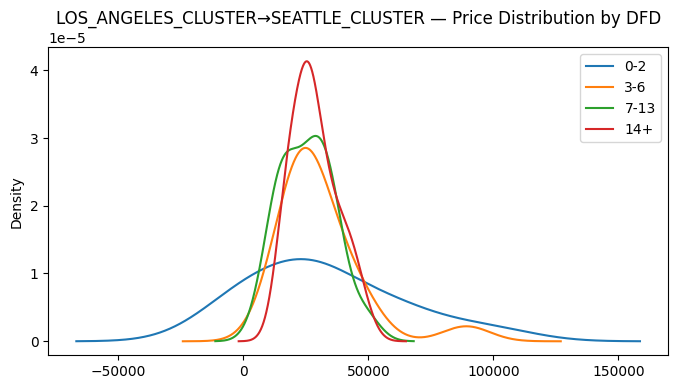

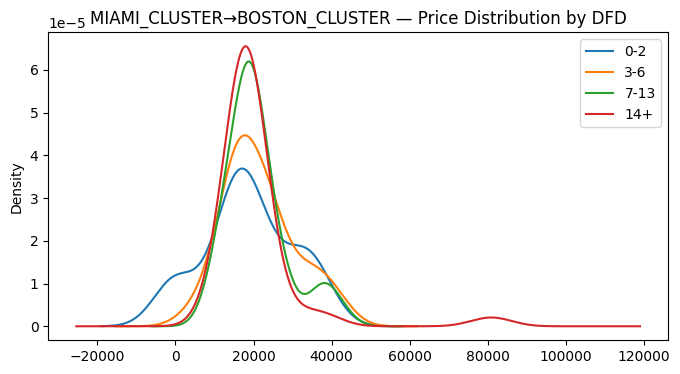

In [39]:
# ------------------------------------------------------------
# STEP: INSPECT RAW DISTRIBUTIONS
# ------------------------------------------------------------

import matplotlib.pyplot as plt

target_corridors = [
    "LOS_ANGELES_CLUSTER→SEATTLE_CLUSTER",
    "MIAMI_CLUSTER→BOSTON_CLUSTER"
]

for corridor in target_corridors:
    temp = df_valid[df_valid["corridor"] == corridor]

    plt.figure(figsize=(8,4))
    
    for bucket in ["0-2", "3-6", "7-13", "14+"]:
        subset = temp[temp["DFD_bucket"] == bucket]["Quote_Total_Cost"]
        if len(subset) > 10:
            subset.plot(kind="kde", label=bucket)

    plt.title(f"{corridor} — Price Distribution by DFD")
    plt.legend()
    plt.show()